In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
# %% Load data
fact_disease = pd.read_csv(r"fact_disease_surveillance_cleaned.csv")
dim_state = pd.read_csv(r"dim_state_cleaned.csv")

print("fact_disease shape:", fact_disease.shape)
print("dim_state shape:", dim_state.shape)

fact_disease shape: (13824, 18)
dim_state shape: (32, 7)


In [3]:
# %% Merge + derive year from report_date_raw
merged = fact_disease.merge(dim_state, on="state_id", how="left")
merged["report_date_raw"] = pd.to_datetime(merged["report_date_raw"])
merged["year"] = merged["report_date_raw"].dt.year

merged["urban_rural_sum"] = merged["urban_cases"] + merged["rural_cases"]
mismatch = (merged["urban_rural_sum"] - merged["total_reported_cases"]).abs()
print("Rows where urban+rural != total_reported_cases:", (mismatch > 0).sum(), "out of", len(merged))

Rows where urban+rural != total_reported_cases: 0 out of 13824


In [5]:
# %% Estimate regional recovery/death splits (proportional to case share)
merged["urban_share"] = merged["urban_cases"] / merged["total_reported_cases"]
merged["rural_share"] = merged["rural_cases"] / merged["total_reported_cases"]

merged["urban_recovered_est"] = merged["recovered_cases"] * merged["urban_share"]
merged["rural_recovered_est"] = merged["recovered_cases"] * merged["rural_share"]

merged["urban_deaths_est"] = merged["deaths"] * merged["urban_share"]
merged["rural_deaths_est"] = merged["deaths"] * merged["rural_share"]

  region  total_cases  pct_of_total
0  Urban      8325042          55.2
1  Rural      6760763          44.8


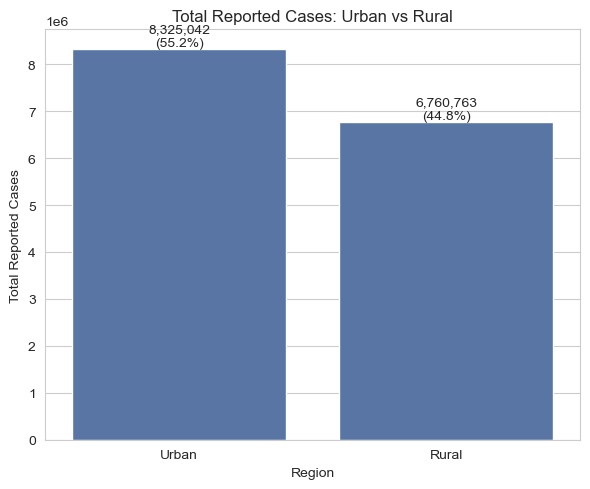

In [7]:
region_cases = pd.DataFrame({
    "region": ["Urban", "Rural"],
    "total_cases": [merged["urban_cases"].sum(), merged["rural_cases"].sum()]
})
region_cases["pct_of_total"] = (region_cases["total_cases"] / region_cases["total_cases"].sum() * 100).round(1)
print(region_cases)

plt.figure(figsize=(6, 5))
sns.barplot(
    data=region_cases,
    x="region",
    y="total_cases",
    color="#4C72B0"
)
plt.title("Total Reported Cases: Urban vs Rural")
plt.xlabel("Region")
plt.ylabel("Total Reported Cases")
for i, row in region_cases.iterrows():
    plt.text(i, row["total_cases"], f"{row['total_cases']:,.0f}\n({row['pct_of_total']}%)",
              ha="center", va="bottom")
plt.tight_layout()
plt.show()

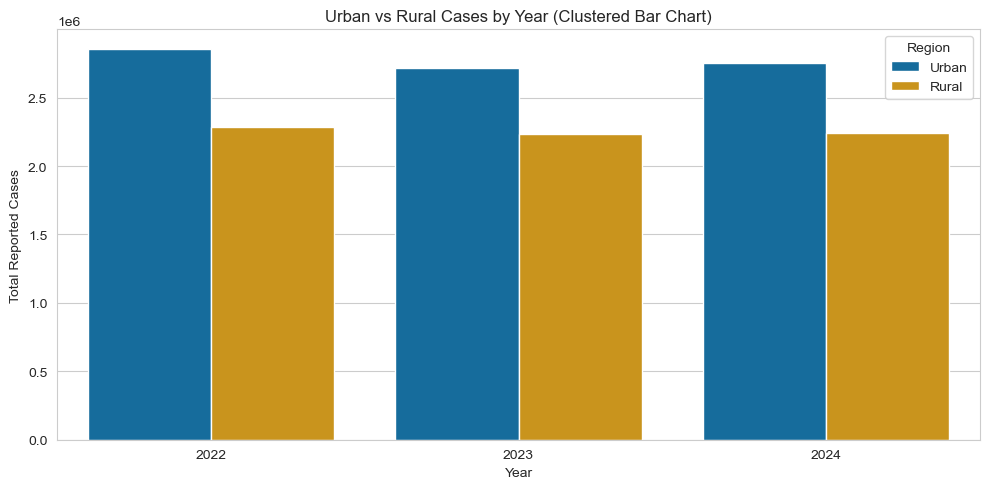

In [27]:
# %% Clustered bar chart -- Urban vs Rural cases by year
yearly_region = (
    merged.groupby("year", as_index=False)[["urban_cases", "rural_cases"]]
    .sum()
    .melt(id_vars="year", value_vars=["urban_cases", "rural_cases"],
          var_name="region", value_name="cases")
)
yearly_region["region"] = yearly_region["region"].str.replace("_cases", "").str.title()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_region, x="year", y="cases", hue="region",
            palette={"Urban": "#0072B2", "Rural": "#E69F00"})
plt.title("Urban vs Rural Cases by Year (Clustered Bar Chart)")
plt.xlabel("Year")
plt.ylabel("Total Reported Cases")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

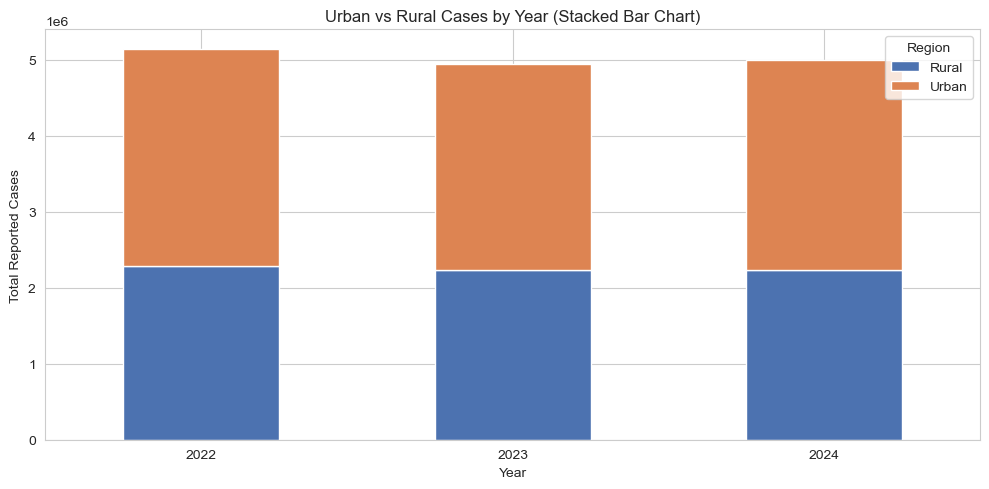

In [9]:
# %% Stacked bar chart -- Urban vs Rural composition by year
pivot_region = yearly_region.pivot(index="year", columns="region", values="cases")

pivot_region.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#4C72B0", "#DD8452"])
plt.title("Urban vs Rural Cases by Year (Stacked Bar Chart)")
plt.xlabel("Year")
plt.ylabel("Total Reported Cases")
plt.xticks(rotation=0)
plt.legend(title="Region")
plt.tight_layout()
plt.show()

  region     recovered    cases  recovery_rate_%
0  Urban  7.017963e+06  8325042            84.30
1  Rural  5.701782e+06  6760763            84.34


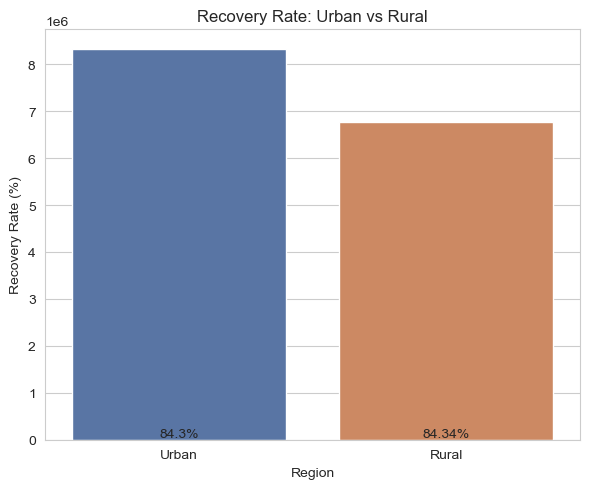

In [14]:
# %% Recovery rate: Urban vs Rural

region_recovery = pd.DataFrame({
    "region": ["Urban", "Rural"],
    "recovered": [merged["urban_recovered_est"].sum(), merged["rural_recovered_est"].sum()],
    "cases": [merged["urban_cases"].sum(), merged["rural_cases"].sum()],
})
region_recovery["recovery_rate_%"] = (region_recovery["recovered"] / region_recovery["cases"] * 100).round(2)
print(region_recovery)

plt.figure(figsize=(6, 5))
sns.barplot(
    data=region_cases,
    x="region",
    y="total_cases",
    hue="region",        
    palette=["#4C72B0", "#DD8452"],
    legend=False         
)
plt.title("Recovery Rate: Urban vs Rural")
plt.xlabel("Region")
plt.ylabel("Recovery Rate (%)")
for i, row in region_recovery.iterrows():
    plt.text(i, row["recovery_rate_%"], f"{row['recovery_rate_%']}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

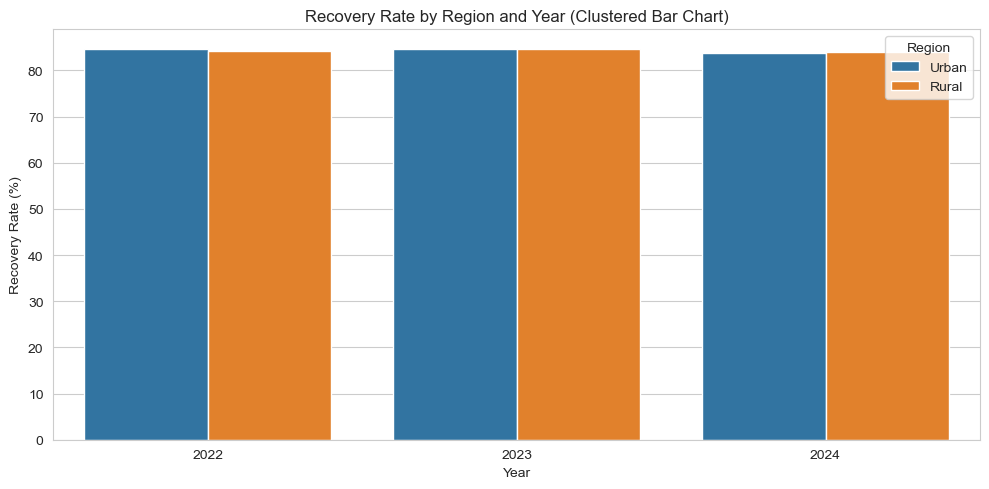

In [25]:
# %% Clustered bar chart -- recovery rate by region and year

yearly_recovery = (
    merged.groupby("year")[["urban_recovered_est", "urban_cases", "rural_recovered_est", "rural_cases"]]
    .apply(lambda d: pd.Series({
        "Urban": d["urban_recovered_est"].sum() / d["urban_cases"].sum() * 100,
        "Rural": d["rural_recovered_est"].sum() / d["rural_cases"].sum() * 100,
    }), include_groups=False)
    .reset_index()
    .melt(id_vars="year", var_name="region", value_name="recovery_rate_%")
)
plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_recovery, x="year", y="recovery_rate_%", hue="region")
plt.title("Recovery Rate by Region and Year (Clustered Bar Chart)")
plt.xlabel("Year")
plt.ylabel("Recovery Rate (%)")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

  region         deaths    cases  mortality_rate_%
0  Urban  146484.111561  8325042              1.76
1  Rural  118564.888439  6760763              1.75


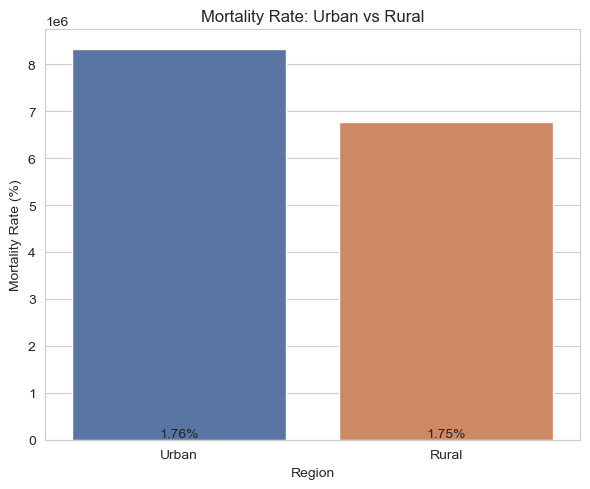

In [26]:
region_mortality = pd.DataFrame({
    "region": ["Urban", "Rural"],
    "deaths": [merged["urban_deaths_est"].sum(), merged["rural_deaths_est"].sum()],
    "cases": [merged["urban_cases"].sum(), merged["rural_cases"].sum()],
})
region_mortality["mortality_rate_%"] = (region_mortality["deaths"] / region_mortality["cases"] * 100).round(2)
print(region_mortality)

plt.figure(figsize=(6, 5))
sns.barplot(data=region_cases, x="region", y="total_cases", hue="region", palette=["#4C72B0", "#DD8452"], legend=False)
plt.title("Mortality Rate: Urban vs Rural")
plt.xlabel("Region")
plt.ylabel("Mortality Rate (%)")
for i, row in region_mortality.iterrows():
    plt.text(i, row["mortality_rate_%"], f"{row['mortality_rate_%']}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

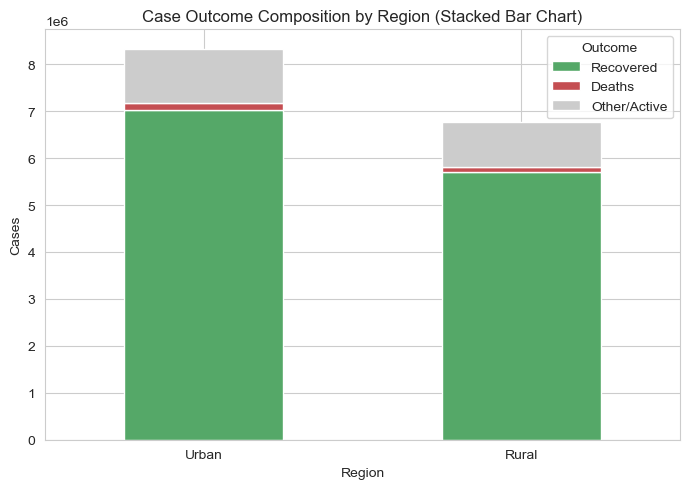

In [23]:
# %% Stacked bar chart -- outcome composition by region
outcomes = pd.DataFrame({
    "region": ["Urban", "Rural"],
    "Recovered": [merged["urban_recovered_est"].sum(), merged["rural_recovered_est"].sum()],
    "Deaths": [merged["urban_deaths_est"].sum(), merged["rural_deaths_est"].sum()],
})
outcomes["Other/Active"] = [
    region_cases.loc[0, "total_cases"] - outcomes.loc[0, ["Recovered", "Deaths"]].sum(),
    region_cases.loc[1, "total_cases"] - outcomes.loc[1, ["Recovered", "Deaths"]].sum(),
]
outcomes = outcomes.set_index("region")

outcomes.plot(kind="bar", stacked=True, figsize=(7, 5), color=["#55A868", "#C44E52", "#CCCCCC"])
plt.title("Case Outcome Composition by Region (Stacked Bar Chart)")
plt.xlabel("Region")
plt.ylabel("Cases")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

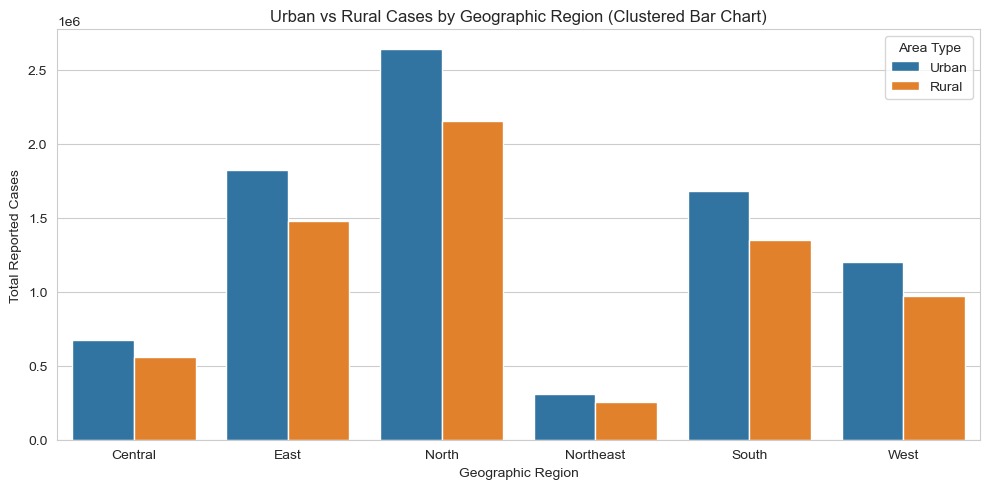

In [24]:
# %% Bonus: cases by dim_state's geographic region (North/South/East/West/Central/Northeast)
geo_region_cases = (
    merged.groupby("region", as_index=False)[["urban_cases", "rural_cases"]]
    .sum()
    .melt(id_vars="region", value_vars=["urban_cases", "rural_cases"],
          var_name="area_type", value_name="cases")
)
geo_region_cases["area_type"] = geo_region_cases["area_type"].str.replace("_cases", "").str.title()

plt.figure(figsize=(10, 5))
sns.barplot(data=geo_region_cases, x="region", y="cases", hue="area_type")
plt.title("Urban vs Rural Cases by Geographic Region (Clustered Bar Chart)")
plt.xlabel("Geographic Region")
plt.ylabel("Total Reported Cases")
plt.legend(title="Area Type")
plt.tight_layout()
plt.show()